In [1]:
import mesa
import matplotlib.pyplot as plt

# --- Scale constants (the physical meaning of the abstract grid) ---
CELL_SIZE_M = 0.5        # each cell is 0.5m x 0.5m (one person's footprint)
SECONDS_PER_STEP = 0.5   # one occupant moves one cell (0.5m) per step at ~1 m/s

# --- Floor plan dimensions (in cells) ---
GRID_WIDTH = 20
GRID_HEIGHT = 15

# --- Exit locations (list of (x, y) cells), from your sketch ---
# Exit 1: bottom-right.  Exit 2: top-left.
EXITS = [(16, 0), (17, 0), (2, 14), (3, 14)]

# Effective door flow under crowded egress: ~0.5 persons/m/s (below the
# 1.3/m/s theoretical max, reflecting density-induced friction per SFPE).
# 1m door * 0.5/m/s * 0.5 s/step = 0.25 persons/step/door.
EXIT_FLOW_PER_STEP = 0.25

In [2]:
class OccupantAgent(mesa.Agent):
    def __init__(self, model):
        super().__init__(model)
        # State: "moving" until they reach an exit, then "escaped".
        self.state = "moving"
        # NFPA 101 pre-movement time: steps this occupant waits before
        # moving. Uniform random 0-60 steps (0-30 sec at 0.5 s/step).
        self.reaction_delay = self.random.randint(0, 60)
        # Counter: how many steps this occupant has existed.
        self.steps_waited = 0

    # Straight-line (Euclidean) distance from MY position to a cell.
    def distance_to(self, cell):
        x1, y1 = self.pos
        x2, y2 = cell
        return ((x1 - x2) ** 2 + (y1 - y2) ** 2) ** 0.5

    # Distance between any two arbitrary cells (used to score moves).
    def _dist(self, a, b):
        return ((a[0] - b[0]) ** 2 + (a[1] - b[1]) ** 2) ** 0.5

    def step(self):
        # Already escaped? Do nothing.
        if self.state == "escaped":
            return

        # NFPA pre-movement: still in reaction-delay window? Count and wait.
        if self.steps_waited < self.reaction_delay:
            self.steps_waited += 1
            return

        # If I'm already standing on an exit cell, don't wander — either
        # pass through (if the door has budget) or HOLD and wait. This
        # prevents the back-and-forth oscillation at congested doors.
        if self.pos in self.model.exits:
            door = self.model.cell_to_door[self.pos]
            if self.model.door_budget[door] >= 1.0:
                self.model.door_budget[door] -= 1.0
                self.state = "escaped"
                self.model.exit_usage[self.pos] += 1
                self.model.grid.remove_agent(self)
            return  # passed or waiting — my turn ends here either way

        # Not at an exit yet — pick my nearest exit.
        target = min(self.model.exits, key=self.distance_to)

        # Look at my 8 neighboring cells (Moore neighborhood).
        neighbors = self.model.grid.get_neighborhood(
            self.pos, moore=True, include_center=False
        )

        # Keep only non-wall neighbors (wall-collision enforcement).
        valid = [c for c in neighbors if c not in self.model.walls]

        # Step to the valid cell closest to my target exit (greedy move).
        if valid:
            best = min(valid, key=lambda c: self._dist(c, target))
            self.model.grid.move_agent(self, best)

In [3]:
def count_escaped(model):
    # Model reporter: how many have escaped so far.
    return model.escaped_count

def evacuation_time_steps(model):
    # Total evacuation time in steps (step when the last person got out).
    if model.escaped_count == model.num_occupants:
        return model.evac_complete_step
    return model.steps

class BuildingModel(mesa.Model):
    def __init__(self, n_occupants=50, seed=None):
        super().__init__(seed=seed)
        self.grid = mesa.space.MultiGrid(GRID_WIDTH, GRID_HEIGHT, torus=False)
        self.exits = set(EXITS)
        self.escaped_count = 0
        self.num_occupants = n_occupants
        self.evac_complete_step = None
        self.exit_usage = {exit_cell: 0 for exit_cell in EXITS}

        # Group the 4 exit cells into 2 physical doors (each 2 cells wide).
        self.doors = {
            "Exit_1": [(16, 0), (17, 0)],
            "Exit_2": [(2, 14), (3, 14)],
        }
        # Each door accumulates a flow "budget" (in persons) each step.
        self.door_budget = {"Exit_1": 0.0, "Exit_2": 0.0}
        # Lookup: given an exit cell, which door is it part of?
        self.cell_to_door = {}
        for door_name, cells in self.doors.items():
            for cell in cells:
                self.cell_to_door[cell] = door_name

        # Build perimeter walls: every edge cell EXCEPT exit gaps.
        self.walls = set()
        for x in range(GRID_WIDTH):
            for y in range(GRID_HEIGHT):
                on_edge = (x == 0 or x == GRID_WIDTH - 1
                           or y == 0 or y == GRID_HEIGHT - 1)
                if on_edge and (x, y) not in self.exits:
                    self.walls.add((x, y))

        # Scatter occupants on random interior (non-wall, non-exit) cells.
        agents = OccupantAgent.create_agents(model=self, n=n_occupants)
        for agent in agents:
            while True:
                x = self.random.randrange(GRID_WIDTH)
                y = self.random.randrange(GRID_HEIGHT)
                if (x, y) not in self.walls and (x, y) not in self.exits:
                    self.grid.place_agent(agent, (x, y))
                    break

        self.datacollector = mesa.DataCollector(
            model_reporters={
                "Escaped": count_escaped,
                "EvacTime": evacuation_time_steps,
            }
        )

    def step(self):
        # Each door gains flow capacity this step, clamped so capacity
        # does not bank up indefinitely (real doors don't save unused flow).
        for door_name in self.door_budget:
            self.door_budget[door_name] += EXIT_FLOW_PER_STEP
            if self.door_budget[door_name] > 1.0:
                self.door_budget[door_name] = 1.0

        self.datacollector.collect(self)
        self.agents.shuffle_do("step")

        # Recount escapees each tick.
        self.escaped_count = sum(
            1 for a in self.agents if a.state == "escaped"
        )
        # Record the step at which the last occupant escaped (once).
        if self.escaped_count == self.num_occupants and self.evac_complete_step is None:
            self.evac_complete_step = self.steps

In [4]:
def evacuation_time_steps(model):
    # Returns the step at which the LAST person escaped (total evac time
    # in steps). If not everyone is out, returns the current step count.
    if model.escaped_count == model.num_occupants:
        return model.evac_complete_step
    return model.steps

In [5]:
model = BuildingModel(50)
for i in range(400):
    model.step()
print(f"Escaped: {model.escaped_count} of 50")

Escaped: 50 of 50


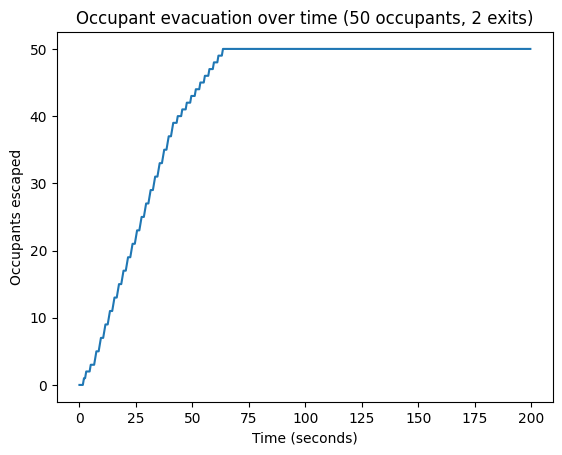

In [6]:
# Pull the model-level time series from the single-run model above.
# get_model_vars_dataframe() returns a table with one row per step
# and one column per reporter ("Escaped" and "EvacTime").
data = model.datacollector.get_model_vars_dataframe()

# Convert the step index into real seconds using our scale constant,
# so the x-axis reads in seconds rather than abstract steps.
data.index = data.index * SECONDS_PER_STEP

# Plot ONLY the "Escaped" column. (Without ["Escaped"], pandas would
# plot every column, including EvacTime, which is why a stray second
# line appeared before — that orange line was the step counter, not
# an occupant count.)
data["Escaped"].plot(
    title="Occupant evacuation over time (50 occupants, 2 exits)",
    xlabel="Time (seconds)",
    ylabel="Occupants escaped",
    legend=False,
)

plt.show()

In [7]:
model = BuildingModel(50)
for i in range(400):
    model.step()

print(f"Escaped: {model.escaped_count} of 50")
print("Exit usage by cell:")
for cell, count in model.exit_usage.items():
    print(f"  Exit cell {cell}: {count} occupants")

Escaped: 50 of 50
Exit usage by cell:
  Exit cell (16, 0): 18 occupants
  Exit cell (17, 0): 5 occupants
  Exit cell (2, 14): 7 occupants
  Exit cell (3, 14): 20 occupants


In [8]:
import pandas as pd

# Parameters: keys must match BuildingModel.__init__ argument names.
# n_occupants is fixed at 50; batch_run will run it many times.
params = {"n_occupants": 50}

results = mesa.batch_run(
    BuildingModel,          # the model CLASS (not an instance)
    parameters=params,
    iterations=50,          # run the whole sim 50 separate times
    max_steps=400,          # each run halts at 150 steps if not done
    number_processes=1,     # 1 = simplest; avoids Windows multiprocessing issues
    data_collection_period=-1,  # -1 = only collect at the END of each run
    display_progress=True,  # show a progress bar
)

# Convert the list of result dicts into a pandas table.
results_df = pd.DataFrame(results)
print(f"Ran {len(results_df)} iterations.")
print(results_df[["iteration", "EvacTime", "Escaped"]].head())

C:\Users\Nathan\AppData\Local\Temp\ipykernel_47588\1896638598.py:7: DeprecationWarning: The `iterations` keyword argument is deprecated. Use `rng` instead (e.g. `iterations=5` is equivalent to `rng=[None] * 5`). See https://mesa.readthedocs.io/latest/migration_guide.html#batch-run
  results = mesa.batch_run(


  0%|          | 0/50 [00:00<?, ?it/s]

Ran 50 iterations.
   iteration  EvacTime  Escaped
0          0       122       50
1          1       112       50
2          2       113       50
3          3       112       50
4          4       112       50


In [9]:
# Pull the evacuation-time column across all 50 runs.
evac_times = results_df["EvacTime"]

# Convert from steps to seconds using our scale constant.
evac_seconds = evac_times * SECONDS_PER_STEP

# Compute summary statistics across all runs.
print("Evacuation time across 50 runs:")
print(f"  Mean:    {evac_seconds.mean():.1f} seconds")
print(f"  Min:     {evac_seconds.min():.1f} seconds (best case)")
print(f"  Max:     {evac_seconds.max():.1f} seconds (worst case)")
print(f"  Std dev: {evac_seconds.std():.1f} seconds (spread)")

Evacuation time across 50 runs:
  Mean:    58.7 seconds
  Min:     52.5 seconds (best case)
  Max:     68.0 seconds (worst case)
  Std dev: 3.7 seconds (spread)


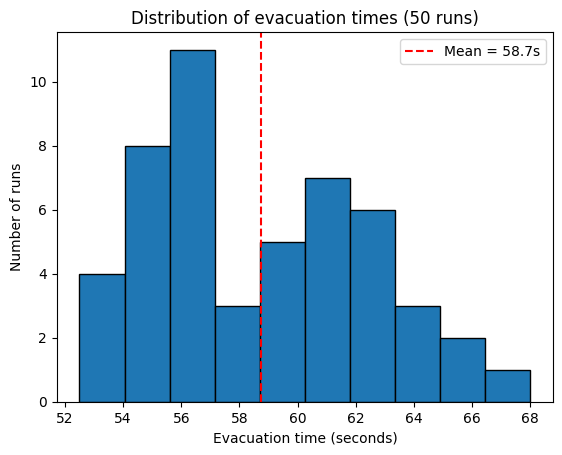

In [10]:
# Plot the distribution of evacuation times across all 50 runs.
plt.hist(
    evac_seconds,        # the 50 evacuation times (in seconds)
    bins=10,             # group them into 10 time buckets
    edgecolor="black",   # outline each bar so they're distinct
)
plt.title("Distribution of evacuation times (50 runs)")
plt.xlabel("Evacuation time (seconds)")
plt.ylabel("Number of runs")

# Draw a vertical line at the mean for reference.
plt.axvline(
    evac_seconds.mean(),
    color="red",
    linestyle="--",
    label=f"Mean = {evac_seconds.mean():.1f}s",
)
plt.legend()
plt.show()

In [11]:
from mesa.visualization import SolaraViz, make_space_component, make_plot_component

# agent_portrayal: SolaraViz calls this for EACH agent to decide how to draw it.
# It must return a dictionary describing the agent's appearance.
def agent_portrayal(agent):
    # Default: a moving occupant — blue dot.
    portrayal = {
        "color": "tab:blue",
        "size": 30,
    }
    # If the occupant is still in its reaction-delay window, show it gray
    # (hasn't started evacuating yet).
    if agent.steps_waited < agent.reaction_delay:
        portrayal["color"] = "tab:gray"
    return portrayal

# Parameter controls: a slider in the UI to set occupant count.
# Keys MUST match the model's __init__ argument names exactly.
model_params = {
    "n_occupants": {
        "type": "SliderInt",
        "value": 50,        # default
        "min": 10,
        "max": 200,
        "step": 10,
        "label": "Number of occupants",
    },
}

# Create a fresh model instance for the visualization.
viz_model = BuildingModel(n_occupants=50)

# Build the dashboard:
#  - make_space_component draws the grid + agents using agent_portrayal
#  - make_plot_component charts the "Escaped" reporter live as it runs
page = SolaraViz(
    viz_model,
    components=[
        make_space_component(agent_portrayal),
        make_plot_component("Escaped"),
    ],
    model_params=model_params,
    name="Fire Egress Simulation v1",
)
page

c:\Users\Nathan\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\mesa\visualization\mpl_space_drawing.py:465: FutureWarning: Returning a dict from agent_portrayal is deprecated and will be removed in Mesa 4.0. Please return an AgentPortrayalStyle instance instead. For more information, refer to the migration guide: https://mesa.readthedocs.io/latest/migration_guide.html#defining-portrayal-components
  arguments = collect_agent_data(space, agent_portrayal, default_size=s_default)


Cannot show ipywidgets in text